In [15]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import os
import ROOT
from scipy import stats
import glob
try:
    # plt.style.use('belle2')
    plt.style.use('belle2_serif')
    # plt.style.use('belle2_modern')
except OSError:
    print("Please install belle2 matplotlib style")   
px = 1/plt.rcParams['figure.dpi']

from main.data_tools.extract_ntuples import get_pd, get_np
from main.draw_tools.decorations import b2helix, watermark
from main.draw_tools.stacking_with_error_bars import MC_stack_plot, MC_stack_plot_density

from main.data_tools.error_bars import make_data_weight
from main.data_tools.query_dataframes import cut_dfs_7types

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
plot_directory = "/media/jykim/T7/saved_plots/DRAW/etapip/MC15rd_generic/gg"
# plot_directory = os.path.dirname(file_path)
if not os.path.exists(plot_directory):
    os.makedirs(plot_directory)

In [17]:
tree = 'etapip_gg'
base_cut = 'Dp_M>0'
# output_dir = os.path.join("MC15rd", f"histograms_{tree}")
# os.makedirs(output_dir, exist_ok=True)

In [18]:
# base_path="/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/EtaHp/MC15rd_loose_v7_260108_nopi0veto"
# dir_list = [
#     f"{base_path}/15rd_jae_e7_18_4S_v3",
#     f"{base_path}/15rd_jae_e20_b26_v1",
#     f"{base_path}/15rd_jae_e20_e26_4S_v2",
#     f"{base_path}/15rd_jae_e21_5S_scan_v1",
#     f"{base_path}/15rd_jae_mori_off_v1",
# ]

# # Sample tags
# tags = ['ccbar', 'uubar', 'ddbar', 'ssbar', 'charged', 'mixed', 'taupair']
# labels = [r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$', r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$', r'$c\bar{c}$']
# tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar']

# # Aggregate all ROOT files by tag
# file_map = {tag: [] for tag in tags}
# for tag in tags:
#     for d in dir_list:
#         path = os.path.join(d, f"{tag}.root")
#         if os.path.exists(path):
#             file_map[tag].append(path)

In [19]:
base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/EtaHp/MC15rd_loose_v7_260108_nopi0veto"
dir_list = [
    f"{base_path}/15rd_jae_e7_18_4S_v3",
    f"{base_path}/15rd_jae_e20_b26_v1",
    f"{base_path}/15rd_jae_e20_e26_4S_v2",
    f"{base_path}/15rd_jae_e21_5S_scan_v1",
    f"{base_path}/15rd_jae_mori_off_v1",
]
tags = ['ccbar', 'uubar', 'ddbar', 'ssbar', 'charged', 'mixed', 'taupair']
labels = [r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$', r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$', r'$c\bar{c}$']
tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar']

file_map = {tag: [] for tag in tags}
for tag in tags:
    for d in dir_list:
        pattern = os.path.join(d, f"{tag}*.root")
        matched_files = glob.glob(pattern)
        matched_files.sort()
        file_map[tag].extend(matched_files)
for tag in tags:
    print(f"{tag}: {len(file_map[tag])} files found")

ccbar: 18 files found
uubar: 18 files found
ddbar: 11 files found
ssbar: 11 files found
charged: 12 files found
mixed: 12 files found
taupair: 11 files found


In [20]:
# Load one file to get variable list
chain = ROOT.TChain(tree)
for path in file_map['ccbar']:
    chain.Add(path)
variables = [b.GetName() for b in chain.GetListOfBranches()]
variables = ['Dp_M','Pip_p','etapip_Eta_daughterDiffOfPhi_0_1','etapip_Eta_daughterAngle_0_1','skimhad','dM_pi0_mask_nonan','dM_pi0_mask_2_nonan']

In [21]:
dataframes = {}
for tag in tags:
    dfs = [get_pd(file=fp, tree=tree, base_filter=base_cut, variables=variables) for fp in file_map[tag]]
    dataframes[tag] = pd.concat(dfs, ignore_index=True)

In [22]:
cut1 = "Pip_p>0.4 & skimhad==1 & abs(etapip_Eta_daughterDiffOfPhi_0_1)<1.8 & etapip_Eta_daughterAngle_0_1<1.6 & dM_pi0_mask_nonan>0.011 & dM_pi0_mask_2_nonan>0.011"

In [23]:
for tag in tags:
    dataframes[tag] =dataframes[tag].query(cut1)

In [24]:
# scale = 1/4
scale = 1
# luminosity=r"$1000\; \mathrm{fb}^{-1}$"
luminosity=""

In [25]:
def wrap_draw(var=str(),data=dataframes,scale=scale,xrange=tuple(),nbins=int(),xlabel=str(), luminosity=luminosity,img_path="",force_range=tuple() ):
    data = [dataframes[tag][var] for tag in tag_order]
    
    # data  = [pd_taupair[var], pd_mixed[var], pd_charged[var],pd_ssbar[var], pd_ddbar[var],pd_uubar[var], pd_ccbar[var]]  
    # labels = [   r'$\tau\bar{\tau}$', r'$B^0\bar{B}^0$', r'$B^+B^-$', r'$s\bar{s}$'  ,r'$d\bar{d}$', r'$u\bar{u}$', r'$c\bar{c}$']
    MC_stack_plot(data, var, scale, xrange, nbins, xlabel=xlabel, labels=labels,title="", unit="[GeV/c^2]",luminosity=luminosity,force_range=force_range,save_repo=img_path)
    plt.tight_layout()

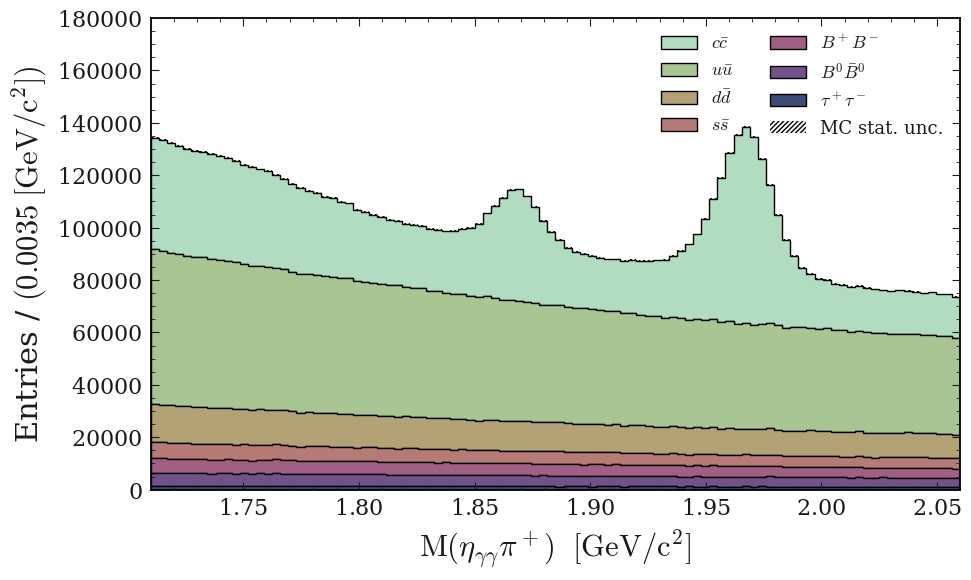

In [27]:
var = 'Dp_M'
# data  = [pd_taupair[var], pd_mixed[var], pd_charged[var],pd_ssbar[var], pd_ddbar[var],pd_uubar[var], pd_ccbar[var]]  

xrange = (1.67,2.1)
xrange = (1.66,2.06)
xrange = (1.71,2.06)

nbins = 100
xlabel = "$\mathrm{M(\eta_{\gamma\gamma}\pi^+)}$"

# img_path = plot_directory + "/MC15ri_Dpetapip_gg_pre_sel_DpM_step0.png"
# img_path = plot_directory + "/MC15ri_Dpetapip_gg_tight_selv1_DpM.png"
# img_path = plot_directory + "/MC15ri_Dpetapip_gg_loose_v0_trainv1.png"

img_path = plot_directory + "/MC15rd_etapip_gg_before_BDT_Dp_M_fixed_cosHel.png"
# img_path = plot_directory + "/MC15ri_Dpetapip_gg_tight_v3_DpM.png"

# plt.ylim(0,150000)
wrap_draw(var=var,data=dataframes,scale=scale,xrange=xrange,nbins=nbins,xlabel=xlabel, luminosity=luminosity,img_path="")
plt.ylim(0,180000)
plt.savefig(img_path)

[      0.       0.       0.       0.       0.       0.       0.       0.
       0.       0.   80980.  289444.  378598.  442558.  481907.  524547.
  574997.  632032.  693050.  768239.  898388. 1070825.  973014.  791456.
  735999.  736557.  790785.  952808. 1020564.  858680.  739812.  667972.
  612484.  560958.  508079.  469665.  430211.  367802.  281727.   80048.
       0.       0.       0.       0.       0.       0.       0.       0.
       0.       0.]
fitst_bin_entries=0.0


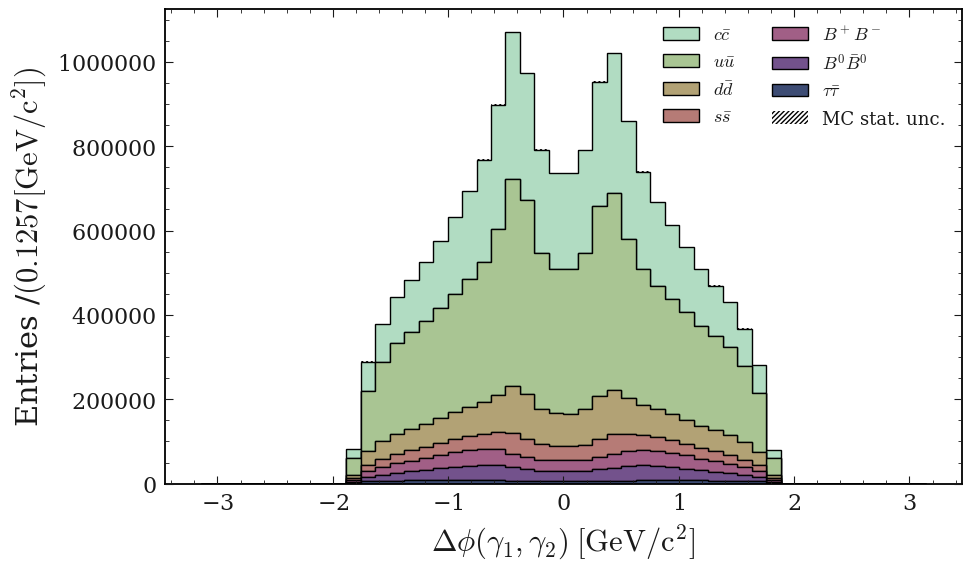

In [38]:
var = 'etapip_Eta_daughterDiffOfPhi_0_1'

xrange = (-math.pi,math.pi)
nbins = 50
xlabel = r"$\Delta \phi(\gamma_1,\gamma_2)$"

# plt.ylim(0,150000)
wrap_draw(var=var,data=dataframes,scale=scale,xrange=xrange,nbins=nbins,xlabel=xlabel, luminosity=luminosity,img_path="")
# plt.ylim(0,90000)
# plt.savefig(img_path)